## Recursive Quantum Reservoir Computing

In [8]:
import math
from dataclasses import dataclass
from typing import Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

import perceval as pcvl
from perceval.components import BS, PS
from perceval.backends import SLOSBackend


@dataclass
class QRC1StepCFG:
    seed: int = 7
    seq_len: int = 30
    horizon: int = 6
    train_frac: float = 0.75
    eps: float = 1e-8

    pca_dim: int = 16

    n_modes: int = 6
    depth: int = 2
    input_scale: float = 0.35
    state_scale: float = 0.20
    leak: float = 0.45

    ridge_alpha: float = 5e-2


cfg1 = QRC1StepCFG()
np.random.seed(cfg1.seed)
print('Perceval version:', pcvl.__version__)



Perceval version: 1.1.0


In [9]:
def load_level1_df() -> pd.DataFrame:
    ds = load_dataset(
        'Quandela/Challenge_Swaptions',
        data_files='level-1_Future_prediction/train.csv',
        split='train',
    )
    df = ds.to_pandas()
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
    return df.sort_values('Date').reset_index(drop=True)


def split_time_ordered(X: np.ndarray, train_frac: float) -> Tuple[np.ndarray, np.ndarray]:
    n = X.shape[0]
    n_tr = int(math.floor(train_frac * n))
    return X[:n_tr], X[n_tr:]


def make_one_step_windows(X: np.ndarray, seq_len: int) -> Tuple[np.ndarray, np.ndarray]:
    T, D = X.shape
    n = T - seq_len
    Xw = np.zeros((n, seq_len, D), dtype=np.float32)
    y = np.zeros((n, D), dtype=np.float32)
    for i in range(n):
        Xw[i] = X[i:i + seq_len]
        y[i] = X[i + seq_len]
    return Xw, y


def make_recursive_eval_windows(X: np.ndarray, seq_len: int, horizon: int) -> Tuple[np.ndarray, np.ndarray]:
    T, D = X.shape
    n = T - (seq_len + horizon) + 1
    Xw = np.zeros((n, seq_len, D), dtype=np.float32)
    Y = np.zeros((n, horizon, D), dtype=np.float32)
    for i in range(n):
        Xw[i] = X[i:i + seq_len]
        Y[i] = X[i + seq_len:i + seq_len + horizon]
    return Xw, Y


def invert_to_vol(Z_pca: np.ndarray, pca: PCA, scaler: StandardScaler, eps: float) -> np.ndarray:
    flat = Z_pca.reshape(-1, Z_pca.shape[-1])
    x_std = pca.inverse_transform(flat)
    x_log = scaler.inverse_transform(x_std)
    x_vol = np.exp(x_log) - eps
    return x_vol.reshape(*Z_pca.shape[:-1], x_vol.shape[-1])


def rmse(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.sqrt(np.mean((a - b) ** 2)))


def mape(a: np.ndarray, b: np.ndarray, eps: float = 1e-8) -> float:
    return float(np.mean(np.abs(a - b) / (np.abs(b) + eps)))


def build_random_interferometer(n_modes: int, depth: int) -> pcvl.Circuit:
    c = pcvl.Circuit(n_modes)
    for _ in range(depth):
        for m in range(n_modes - 1):
            theta = float(np.random.uniform(0, 2 * np.pi))
            phi = float(np.random.uniform(0, 2 * np.pi))
            c.add((m, m + 1), BS(theta=theta))
            c.add(m, PS(phi))
    return c


class ResidualQRC1Step:
    def __init__(self, d_in: int, cfg: QRC1StepCFG):
        self.d_in = d_in
        self.cfg = cfg

        self.W_in = np.random.uniform(-1.0, 1.0, size=(cfg.n_modes, d_in)).astype(np.float32)
        self.W_s = np.random.uniform(-1.0, 1.0, size=(cfg.n_modes, cfg.n_modes)).astype(np.float32)

        self.pre = build_random_interferometer(cfg.n_modes, cfg.depth)
        self.post = build_random_interferometer(cfg.n_modes, cfg.depth)
        self.backend = SLOSBackend()
        self.input_state = pcvl.BasicState([1] + [0] * (cfg.n_modes - 1))

        self.out_states = []
        for j in range(cfg.n_modes):
            occ = [0] * cfg.n_modes
            occ[j] = 1
            self.out_states.append(pcvl.BasicState(occ))

        self.f_dim = 1 + 2 * cfg.n_modes

    def _probs_from_phases(self, phases: np.ndarray) -> np.ndarray:
        c = pcvl.Circuit(self.cfg.n_modes)
        c.add(0, self.pre)
        for m in range(self.cfg.n_modes):
            c.add(m, PS(float(phases[m])))
        c.add(0, self.post)

        self.backend.set_circuit(c)
        self.backend.set_input_state(self.input_state)
        pd = self.backend.prob_distribution()

        p = np.array([float(pd[s]) if s in pd else 0.0 for s in self.out_states], dtype=np.float32)
        return p

    def _sequence_feature(self, seq: np.ndarray) -> np.ndarray:
        state = np.zeros(self.cfg.n_modes, dtype=np.float32)
        for t in range(seq.shape[0]):
            x_t = seq[t]
            z = self.cfg.input_scale * (self.W_in @ x_t) + self.cfg.state_scale * (self.W_s @ state)
            phases = np.mod(z, 2 * np.pi)
            p = self._probs_from_phases(phases)
            state = (1.0 - self.cfg.leak) * state + self.cfg.leak * p
        return np.concatenate([np.array([1.0], dtype=np.float32), state, state ** 2], axis=0)

    def features(self, X_win: np.ndarray, verbose: bool = True) -> np.ndarray:
        N = X_win.shape[0]
        R = np.zeros((N, self.f_dim), dtype=np.float32)
        for i in range(N):
            R[i] = self._sequence_feature(X_win[i])
            if verbose and (i + 1) % 200 == 0:
                print(f'features: {i + 1}/{N}')
        return R


def recursive_rollout(model: ResidualQRC1Step, readout: Ridge, X_init: np.ndarray, horizon: int) -> np.ndarray:
    N, L, D = X_init.shape
    preds = np.zeros((N, horizon, D), dtype=np.float32)

    for i in range(N):
        window = X_init[i].copy()
        for h in range(horizon):
            r = model._sequence_feature(window)[None, :]
            delta = readout.predict(r).astype(np.float32)[0]
            y_next = window[-1] + delta
            preds[i, h] = y_next
            window = np.concatenate([window[1:], y_next[None, :]], axis=0)
    return preds



def feature_diagnostics(model: ResidualQRC1Step, X_win: np.ndarray, n: int = 64):
    n = min(n, len(X_win))
    R = model.features(X_win[:n], verbose=False)
    per_col_std = R.std(axis=0)
    print('feature matrix shape:', R.shape)
    print('mean std across features:', float(per_col_std.mean()))
    print('min/std/max feature std:', float(per_col_std.min()), float(per_col_std.mean()), float(per_col_std.max()))
    return per_col_std



In [10]:
# Data pipeline: log-vol -> train/val split -> standardize on train -> PCA on train

df = load_level1_df()
feature_cols = [c for c in df.columns if c != 'Date']

X_vol = df[feature_cols].to_numpy(dtype=np.float32)
X_log = np.log(X_vol + cfg1.eps).astype(np.float32)

X_train_log, X_val_log = split_time_ordered(X_log, cfg1.train_frac)

scaler_1 = StandardScaler()
X_train_std = scaler_1.fit_transform(X_train_log)
X_val_std = scaler_1.transform(X_val_log)

pca_dim = min(cfg1.pca_dim, X_train_std.shape[1])
pca_1 = PCA(n_components=pca_dim, random_state=cfg1.seed, whiten=True)
Z_train = pca_1.fit_transform(X_train_std).astype(np.float32)
Z_val = pca_1.transform(X_val_std).astype(np.float32)

# One-step training windows
Xtr_1, ytr_1 = make_one_step_windows(Z_train, cfg1.seq_len)
Xva_1, yva_1 = make_one_step_windows(Z_val, cfg1.seq_len)

# Residual targets in PCA space
last_tr = Xtr_1[:, -1, :]
last_va = Xva_1[:, -1, :]
ytr_res = ytr_1 - last_tr
yva_res = yva_1 - last_va

print('train one-step windows:', Xtr_1.shape, ytr_1.shape)
print('val one-step windows  :', Xva_1.shape, yva_1.shape)

# Train residual RC
qrc_1 = ResidualQRC1Step(d_in=pca_dim, cfg=cfg1)
R_tr = qrc_1.features(Xtr_1)
R_va = qrc_1.features(Xva_1)

readout_1 = Ridge(alpha=cfg1.ridge_alpha, fit_intercept=False)
readout_1.fit(R_tr, ytr_res)

# One-step metrics (vol space)
ytr_1_hat = (last_tr + readout_1.predict(R_tr)).astype(np.float32)
yva_1_hat = (last_va + readout_1.predict(R_va)).astype(np.float32)

tr_pred_vol_1 = invert_to_vol(ytr_1_hat, pca_1, scaler_1, cfg1.eps)
tr_true_vol_1 = invert_to_vol(ytr_1, pca_1, scaler_1, cfg1.eps)
va_pred_vol_1 = invert_to_vol(yva_1_hat, pca_1, scaler_1, cfg1.eps)
va_true_vol_1 = invert_to_vol(yva_1, pca_1, scaler_1, cfg1.eps)

print('ONE-STEP TRAIN RMSE:', rmse(tr_pred_vol_1, tr_true_vol_1), 'MAPE:', mape(tr_pred_vol_1, tr_true_vol_1, eps=cfg1.eps))
print('ONE-STEP VAL   RMSE:', rmse(va_pred_vol_1, va_true_vol_1), 'MAPE:', mape(va_pred_vol_1, va_true_vol_1, eps=cfg1.eps))



train one-step windows: (340, 30, 16) (340, 16)
val one-step windows  : (94, 30, 16) (94, 16)
features: 200/340
ONE-STEP TRAIN RMSE: 0.004069806542247534 MAPE: 0.014376180246472359
ONE-STEP VAL   RMSE: 0.00352687481790781 MAPE: 0.014180812053382397


RECURSIVE-6 TRAIN RMSE: 0.007875818759202957 MAPE: 0.02639920637011528
RECURSIVE-6 VAL   RMSE: 0.006694589741528034 MAPE: 0.026700137183070183


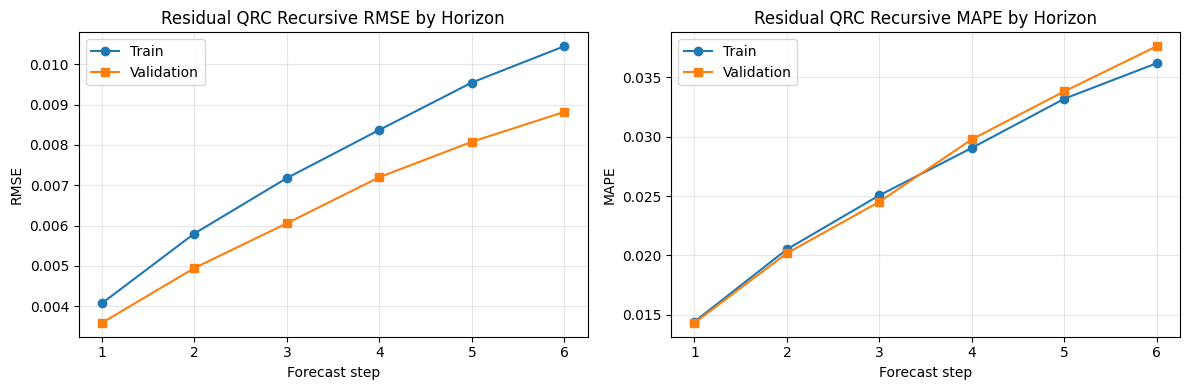

In [11]:
# Recursive 6-step evaluation using the one-step residual model

Xtr_rec, Ytr_rec = make_recursive_eval_windows(Z_train, cfg1.seq_len, cfg1.horizon)
Xva_rec, Yva_rec = make_recursive_eval_windows(Z_val, cfg1.seq_len, cfg1.horizon)

Ytr_rec_hat = recursive_rollout(qrc_1, readout_1, Xtr_rec, horizon=cfg1.horizon)
Yva_rec_hat = recursive_rollout(qrc_1, readout_1, Xva_rec, horizon=cfg1.horizon)

tr_pred_vol_rec = invert_to_vol(Ytr_rec_hat, pca_1, scaler_1, cfg1.eps)
tr_true_vol_rec = invert_to_vol(Ytr_rec, pca_1, scaler_1, cfg1.eps)
va_pred_vol_rec = invert_to_vol(Yva_rec_hat, pca_1, scaler_1, cfg1.eps)
va_true_vol_rec = invert_to_vol(Yva_rec, pca_1, scaler_1, cfg1.eps)

print('RECURSIVE-6 TRAIN RMSE:', rmse(tr_pred_vol_rec, tr_true_vol_rec), 'MAPE:', mape(tr_pred_vol_rec, tr_true_vol_rec, eps=cfg1.eps))
print('RECURSIVE-6 VAL   RMSE:', rmse(va_pred_vol_rec, va_true_vol_rec), 'MAPE:', mape(va_pred_vol_rec, va_true_vol_rec, eps=cfg1.eps))


def horizon_metrics(pred_vol: np.ndarray, true_vol: np.ndarray, eps: float = 1e-8):
    H = pred_vol.shape[1]
    rmse_h, mape_h = [], []
    for h in range(H):
        rmse_h.append(rmse(pred_vol[:, h, :], true_vol[:, h, :]))
        mape_h.append(mape(pred_vol[:, h, :], true_vol[:, h, :], eps=eps))
    return np.array(rmse_h), np.array(mape_h)


tr_rmse_h, tr_mape_h = horizon_metrics(tr_pred_vol_rec, tr_true_vol_rec, eps=cfg1.eps)
va_rmse_h, va_mape_h = horizon_metrics(va_pred_vol_rec, va_true_vol_rec, eps=cfg1.eps)

steps = np.arange(1, cfg1.horizon + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(steps, tr_rmse_h, marker='o', label='Train')
ax[0].plot(steps, va_rmse_h, marker='s', label='Validation')
ax[0].set_title('Residual QRC Recursive RMSE by Horizon')
ax[0].set_xlabel('Forecast step')
ax[0].set_ylabel('RMSE')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].plot(steps, tr_mape_h, marker='o', label='Train')
ax[1].plot(steps, va_mape_h, marker='s', label='Validation')
ax[1].set_title('Residual QRC Recursive MAPE by Horizon')
ax[1].set_xlabel('Forecast step')
ax[1].set_ylabel('MAPE')
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()



In [12]:
# Hyperparameter tuning for one-step residual QRC (validation RMSE primary)

import itertools


def evaluate_qrc_config(cfg_t, Xtr, ytr, Xva, yva, pca_obj, scaler_obj, eps):
    # residual targets
    last_tr = Xtr[:, -1, :]
    last_va = Xva[:, -1, :]
    ytr_res = ytr - last_tr

    model = ResidualQRC1Step(d_in=Xtr.shape[-1], cfg=cfg_t)
    R_tr = model.features(Xtr, verbose=False)
    R_va = model.features(Xva, verbose=False)

    ro = Ridge(alpha=cfg_t.ridge_alpha, fit_intercept=False)
    ro.fit(R_tr, ytr_res)

    ytr_hat = (last_tr + ro.predict(R_tr)).astype(np.float32)
    yva_hat = (last_va + ro.predict(R_va)).astype(np.float32)

    tr_pred_vol = invert_to_vol(ytr_hat, pca_obj, scaler_obj, eps)
    tr_true_vol = invert_to_vol(ytr, pca_obj, scaler_obj, eps)
    va_pred_vol = invert_to_vol(yva_hat, pca_obj, scaler_obj, eps)
    va_true_vol = invert_to_vol(yva, pca_obj, scaler_obj, eps)

    return {
        'model': model,
        'readout': ro,
        'train_rmse': rmse(tr_pred_vol, tr_true_vol),
        'train_mape': mape(tr_pred_vol, tr_true_vol, eps=eps),
        'val_rmse': rmse(va_pred_vol, va_true_vol),
        'val_mape': mape(va_pred_vol, va_true_vol, eps=eps),
    }


# Speed knob: tune on subset, then retrain best on full windows
max_train_tune = min(700, len(Xtr_1))
max_val_tune = min(250, len(Xva_1))
Xtr_tune, ytr_tune = Xtr_1[:max_train_tune], ytr_1[:max_train_tune]
Xva_tune, yva_tune = Xva_1[:max_val_tune], yva_1[:max_val_tune]

print('tuning subset train:', Xtr_tune.shape, 'val:', Xva_tune.shape)

# quick sanity check that reservoir features are not collapsed
_tmp_model = ResidualQRC1Step(d_in=Xtr_tune.shape[-1], cfg=cfg1)
_ = feature_diagnostics(_tmp_model, Xtr_tune, n=64)


# Small but meaningful grid; adjust if you want broader search
param_grid = {
    'n_modes': [4, 6],
    'depth': [1, 2],
    'input_scale': [0.20, 0.35, 0.50],
    'state_scale': [0.10, 0.20, 0.35],
    'leak': [0.30, 0.45, 0.65],
    'ridge_alpha': [1e-3, 1e-2, 5e-2, 1e-1],
}

keys = list(param_grid.keys())
all_combos = list(itertools.product(*[param_grid[k] for k in keys]))
print('full grid size:', len(all_combos))

max_trials = min(24, len(all_combos))
rng = np.random.default_rng(cfg1.seed)
chosen_idx = rng.choice(len(all_combos), size=max_trials, replace=False)
combos = [all_combos[j] for j in chosen_idx]
print('configs evaluated:', len(combos))

results = []
for i, vals in enumerate(combos, start=1):
    cfg_t = QRC1StepCFG(
        seed=cfg1.seed,
        seq_len=cfg1.seq_len,
        horizon=cfg1.horizon,
        train_frac=cfg1.train_frac,
        eps=cfg1.eps,
        pca_dim=cfg1.pca_dim,
        n_modes=vals[0],
        depth=vals[1],
        input_scale=vals[2],
        state_scale=vals[3],
        leak=vals[4],
        ridge_alpha=vals[5],
    )

    np.random.seed(cfg_t.seed + i)
    out = evaluate_qrc_config(cfg_t, Xtr_tune, ytr_tune, Xva_tune, yva_tune, pca_1, scaler_1, cfg_t.eps)
    row = {
        'idx': i,
        'n_modes': cfg_t.n_modes,
        'depth': cfg_t.depth,
        'input_scale': cfg_t.input_scale,
        'state_scale': cfg_t.state_scale,
        'leak': cfg_t.leak,
        'ridge_alpha': cfg_t.ridge_alpha,
        'train_rmse': out['train_rmse'],
        'train_mape': out['train_mape'],
        'val_rmse': out['val_rmse'],
        'val_mape': out['val_mape'],
    }
    results.append(row)

    if i % 10 == 0 or i == len(combos):
        print(f'completed {i}/{len(combos)} | val_rmse={row["val_rmse"]:.6f} val_mape={row["val_mape"]:.6f}')

res_df = pd.DataFrame(results).sort_values(['val_rmse', 'val_mape']).reset_index(drop=True)
print('Top 10 by validation RMSE:')
display(res_df.head(10))

best_cfg_row = res_df.iloc[0].to_dict()
print('Best config:', best_cfg_row)





tuning subset train: (340, 30, 16) val: (94, 30, 16)
feature matrix shape: (64, 13)
mean std across features: 0.039469163864851
min/std/max feature std: 0.0 0.039469163864851 0.12440478801727295
full grid size: 432
configs evaluated: 24
completed 10/24 | val_rmse=0.003628 val_mape=0.014733
completed 20/24 | val_rmse=0.003549 val_mape=0.014323
completed 24/24 | val_rmse=0.003526 val_mape=0.014104
Top 10 by validation RMSE:


,idx,n_modes,depth,input_scale,state_scale,leak,ridge_alpha,train_rmse,train_mape,val_rmse,val_mape
0,9,4,1,0.20,0.10,0.30,0.050,0.004056,0.014381,0.003493,0.014065
1,1,6,1,0.35,0.35,0.45,0.010,0.004058,0.014360,0.003517,0.014095
2,3,6,2,0.35,0.35,0.30,0.001,0.004004,0.014283,0.003525,0.014442
3,17,4,1,0.35,0.20,0.30,0.050,0.004064,0.014448,0.003525,0.014118
4,24,6,2,0.20,0.20,0.30,0.100,0.004063,0.014427,0.003526,0.014104
5,18,4,2,0.20,0.10,0.65,0.100,0.004073,0.014466,0.003528,0.014144
6,8,4,1,0.35,0.20,0.45,0.100,0.004065,0.014456,0.003528,0.014096
7,22,4,2,0.20,0.20,0.65,0.050,0.004041,0.014346,0.003532,0.014225
8,21,4,2,0.20,0.20,0.45,0.010,0.004049,0.014388,0.003534,0.014158
9,16,4,1,0.20,0.20,0.65,0.100,0.004072,0.014439,0.003534,0.014167


Best config: {'idx': 9.0, 'n_modes': 4.0, 'depth': 1.0, 'input_scale': 0.2, 'state_scale': 0.1, 'leak': 0.3, 'ridge_alpha': 0.05, 'train_rmse': 0.004056090954691172, 'train_mape': 0.014380605891346931, 'val_rmse': 0.003493201220408082, 'val_mape': 0.014065139926970005}


Best tuned config:
QRC1StepCFG(seed=7, seq_len=30, horizon=6, train_frac=0.75, eps=1e-08, pca_dim=16, n_modes=4, depth=1, input_scale=0.2, state_scale=0.1, leak=0.3, ridge_alpha=0.05)
Model comparison:


,model,one_step_train_rmse,one_step_train_mape,one_step_val_rmse,one_step_val_mape,rec6_train_rmse,rec6_train_mape,rec6_val_rmse,rec6_val_mape
0,Residual QRC (best tuned),0.004053,0.014413,0.003533,0.014140,0.007761,0.026179,0.006778,0.027079
1,Persistence,0.004082,0.014477,0.003527,0.014168,0.007984,0.026903,0.006691,0.026742


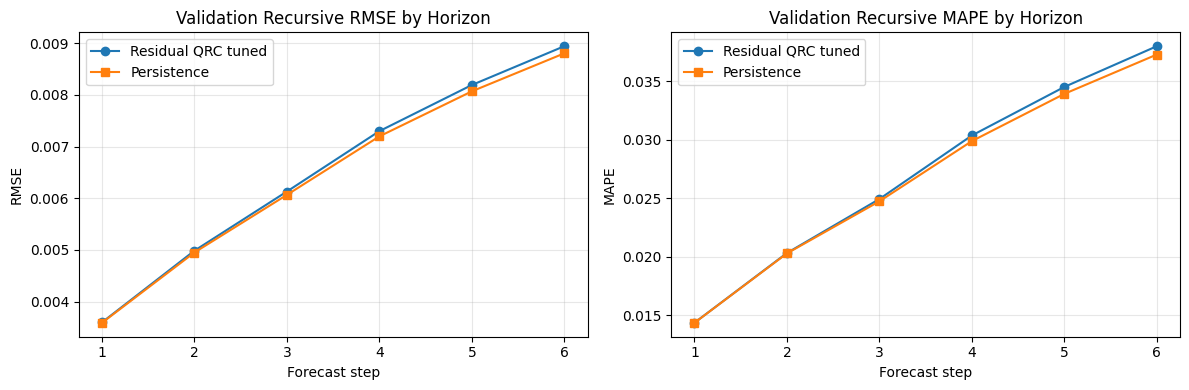

In [ ]:
# Retrain best config on full one-step data, then compare against persistence baseline

best_cfg = QRC1StepCFG(
    seed=cfg1.seed,
    seq_len=cfg1.seq_len,
    horizon=cfg1.horizon,
    train_frac=cfg1.train_frac,
    eps=cfg1.eps,
    pca_dim=cfg1.pca_dim,
    n_modes=int(best_cfg_row['n_modes']),
    depth=int(best_cfg_row['depth']),
    input_scale=float(best_cfg_row['input_scale']),
    state_scale=float(best_cfg_row['state_scale']),
    leak=float(best_cfg_row['leak']),
    ridge_alpha=float(best_cfg_row['ridge_alpha']),
)

np.random.seed(best_cfg.seed + 999)
best_model = ResidualQRC1Step(d_in=Xtr_1.shape[-1], cfg=best_cfg)

# one-step train
last_tr_full = Xtr_1[:, -1, :]
last_va_full = Xva_1[:, -1, :]
ytr_res_full = ytr_1 - last_tr_full

R_tr_full = best_model.features(Xtr_1, verbose=False)
R_va_full = best_model.features(Xva_1, verbose=False)

best_readout = Ridge(alpha=best_cfg.ridge_alpha, fit_intercept=False)
best_readout.fit(R_tr_full, ytr_res_full)

# one-step predictions
ytr_best_1 = (last_tr_full + best_readout.predict(R_tr_full)).astype(np.float32)
yva_best_1 = (last_va_full + best_readout.predict(R_va_full)).astype(np.float32)

tr_best_1_vol = invert_to_vol(ytr_best_1, pca_1, scaler_1, best_cfg.eps)
va_best_1_vol = invert_to_vol(yva_best_1, pca_1, scaler_1, best_cfg.eps)
tr_true_1_vol = invert_to_vol(ytr_1, pca_1, scaler_1, best_cfg.eps)
va_true_1_vol = invert_to_vol(yva_1, pca_1, scaler_1, best_cfg.eps)

# persistence one-step
ytr_persist_1 = last_tr_full.astype(np.float32)
yva_persist_1 = last_va_full.astype(np.float32)

tr_persist_1_vol = invert_to_vol(ytr_persist_1, pca_1, scaler_1, best_cfg.eps)
va_persist_1_vol = invert_to_vol(yva_persist_1, pca_1, scaler_1, best_cfg.eps)

# recursive-6 windows
Xtr_rec, Ytr_rec = make_recursive_eval_windows(Z_train, best_cfg.seq_len, best_cfg.horizon)
Xva_rec, Yva_rec = make_recursive_eval_windows(Z_val, best_cfg.seq_len, best_cfg.horizon)

Ytr_best_rec = recursive_rollout(best_model, best_readout, Xtr_rec, horizon=best_cfg.horizon)
Yva_best_rec = recursive_rollout(best_model, best_readout, Xva_rec, horizon=best_cfg.horizon)

Ytr_persist_rec = np.repeat(Xtr_rec[:, -1:, :], best_cfg.horizon, axis=1)
Yva_persist_rec = np.repeat(Xva_rec[:, -1:, :], best_cfg.horizon, axis=1)

tr_best_rec_vol = invert_to_vol(Ytr_best_rec, pca_1, scaler_1, best_cfg.eps)
va_best_rec_vol = invert_to_vol(Yva_best_rec, pca_1, scaler_1, best_cfg.eps)
tr_persist_rec_vol = invert_to_vol(Ytr_persist_rec, pca_1, scaler_1, best_cfg.eps)
va_persist_rec_vol = invert_to_vol(Yva_persist_rec, pca_1, scaler_1, best_cfg.eps)
tr_true_rec_vol = invert_to_vol(Ytr_rec, pca_1, scaler_1, best_cfg.eps)
va_true_rec_vol = invert_to_vol(Yva_rec, pca_1, scaler_1, best_cfg.eps)

comparison = pd.DataFrame([
    {
        'model': 'Residual QRC (best tuned)',
        'one_step_train_rmse': rmse(tr_best_1_vol, tr_true_1_vol),
        'one_step_train_mape': mape(tr_best_1_vol, tr_true_1_vol, eps=best_cfg.eps),
        'one_step_val_rmse': rmse(va_best_1_vol, va_true_1_vol),
        'one_step_val_mape': mape(va_best_1_vol, va_true_1_vol, eps=best_cfg.eps),
        'rec6_train_rmse': rmse(tr_best_rec_vol, tr_true_rec_vol),
        'rec6_train_mape': mape(tr_best_rec_vol, tr_true_rec_vol, eps=best_cfg.eps),
        'rec6_val_rmse': rmse(va_best_rec_vol, va_true_rec_vol),
        'rec6_val_mape': mape(va_best_rec_vol, va_true_rec_vol, eps=best_cfg.eps),
    },
    {
        'model': 'Persistence',
        'one_step_train_rmse': rmse(tr_persist_1_vol, tr_true_1_vol),
        'one_step_train_mape': mape(tr_persist_1_vol, tr_true_1_vol, eps=best_cfg.eps),
        'one_step_val_rmse': rmse(va_persist_1_vol, va_true_1_vol),
        'one_step_val_mape': mape(va_persist_1_vol, va_true_1_vol, eps=best_cfg.eps),
        'rec6_train_rmse': rmse(tr_persist_rec_vol, tr_true_rec_vol),
        'rec6_train_mape': mape(tr_persist_rec_vol, tr_true_rec_vol, eps=best_cfg.eps),
        'rec6_val_rmse': rmse(va_persist_rec_vol, va_true_rec_vol),
        'rec6_val_mape': mape(va_persist_rec_vol, va_true_rec_vol, eps=best_cfg.eps),
    }
])

print('Best tuned config:')
print(best_cfg)
print('Model comparison:')
display(comparison)

# Horizon-wise validation comparison for recursive forecasts
va_best_rmse_h, va_best_mape_h = horizon_metrics(va_best_rec_vol, va_true_rec_vol, eps=best_cfg.eps)
va_pers_rmse_h, va_pers_mape_h = horizon_metrics(va_persist_rec_vol, va_true_rec_vol, eps=best_cfg.eps)

steps = np.arange(1, best_cfg.horizon + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(steps, va_best_rmse_h, marker='o', label='Residual QRC tuned')
ax[0].plot(steps, va_pers_rmse_h, marker='s', label='Persistence')
ax[0].set_title('Validation Recursive RMSE by Horizon')
ax[0].set_xlabel('Forecast step')
ax[0].set_ylabel('RMSE')
ax[0].grid(True, alpha=0.3)
ax[0].legend()

ax[1].plot(steps, va_best_mape_h, marker='o', label='Residual QRC tuned')
ax[1].plot(steps, va_pers_mape_h, marker='s', label='Persistence')
ax[1].set_title('Validation Recursive MAPE by Horizon')
ax[1].set_xlabel('Forecast step')
ax[1].set_ylabel('MAPE')
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()

In [21]:
# QRC Model (1 step): predict next 6 from last 30 validation days, then compare with test.xlsx

import numpy as np
import pandas as pd

# Choose tuned model if available; otherwise fall back to baseline qrc_1/readout_1
if ('best_model' in globals()) and ('best_readout' in globals()) and ('best_cfg' in globals()):
    qrc_eval_model = best_model
    qrc_eval_readout = best_readout
    qrc_horizon = int(best_cfg.horizon)
    qrc_eps = float(best_cfg.eps)
else:
    if ('qrc_1' not in globals()) or ('readout_1' not in globals()):
        raise RuntimeError('Run QRC training cells first (baseline or tuned) before this comparison cell.')
    qrc_eval_model = qrc_1
    qrc_eval_readout = readout_1
    qrc_horizon = int(cfg1.horizon)
    qrc_eps = float(cfg1.eps)

# Build last-30 window from validation PCA series
X_last_qrc = Z_val[-cfg1.seq_len:][None, :, :].astype(np.float32)  # (1, 30, pca_dim)

# Recursive rollout in PCA space
Y_qrc_pred_pca = recursive_rollout(qrc_eval_model, qrc_eval_readout, X_last_qrc, horizon=qrc_horizon)[0]  # (6, pca_dim)

# Convert back to volatility space
Y_qrc_pred_vol = invert_to_vol(Y_qrc_pred_pca, pca_1, scaler_1, qrc_eps)  # (6, 224)

# Build prediction dataframe in original column order
feature_cols = [c for c in df_l1.columns if c != 'Date']
last_date = pd.to_datetime(df_l1['Date']).iloc[-1]
pred_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=qrc_horizon, freq='D')

qrc_pred_next6_df = pd.DataFrame(Y_qrc_pred_vol, columns=feature_cols)
qrc_pred_next6_df.insert(0, 'Date', pred_dates)

print('QRC predicted next 6 rows:')
display(qrc_pred_next6_df)

# Read test.xlsx and compare
try:
    test_df = pd.read_excel('test.xlsx')
except Exception as e:
    raise RuntimeError(
        'Could not read test.xlsx. Install openpyxl in your environment, then rerun. '
        f'Original error: {e}'
    )

if len(test_df) < qrc_horizon:
    raise ValueError(f'test.xlsx has only {len(test_df)} rows; need at least {qrc_horizon}.')

actual_qrc_6 = test_df.iloc[:qrc_horizon].copy()
missing_cols = [c for c in feature_cols if c not in actual_qrc_6.columns]
if missing_cols:
    raise ValueError(f'test.xlsx is missing {len(missing_cols)} expected columns. Example: {missing_cols[:5]}')

pred_arr = qrc_pred_next6_df[feature_cols].to_numpy(dtype=np.float64)
true_arr = actual_qrc_6[feature_cols].to_numpy(dtype=np.float64)

rmse_qrc = float(np.sqrt(np.mean((pred_arr - true_arr) ** 2)))
mape_qrc = float(100.0 * np.mean(np.abs(pred_arr - true_arr) / (np.abs(true_arr) + 1e-8)))

print('QRC next-6 vs test.xlsx')
print('RMSE:', rmse_qrc)
print('MAPE (%):', mape_qrc)

rmse_by_step = np.sqrt(np.mean((pred_arr - true_arr) ** 2, axis=1))
mape_by_step = 100.0 * np.mean(np.abs(pred_arr - true_arr) / (np.abs(true_arr) + 1e-8), axis=1)

qrc_compare_rows = pd.DataFrame({
    'step_ahead': np.arange(1, qrc_horizon + 1),
    'rmse': rmse_by_step,
    'mape_pct': mape_by_step,
})

print('Per-step metrics:')
display(qrc_compare_rows)



QRC predicted next 6 rows:


,Date,Tenor : 1; Maturity : 0.0833333333333333,Tenor : 2; Maturity : 0.0833333333333333,Tenor : 3; Maturity : 0.0833333333333333,Tenor : 4; Maturity : 0.0833333333333333,Tenor : 5; Maturity : 0.0833333333333333,Tenor : 6; Maturity : 0.0833333333333333,Tenor : 7; Maturity : 0.0833333333333333,Tenor : 8; Maturity : 0.0833333333333333,Tenor : 9; Maturity : 0.0833333333333333,...,Tenor : 5; Maturity : 30,Tenor : 6; Maturity : 30,Tenor : 7; Maturity : 30,Tenor : 8; Maturity : 30,Tenor : 9; Maturity : 30,Tenor : 10; Maturity : 30,Tenor : 15; Maturity : 30,Tenor : 20; Maturity : 30,Tenor : 25; Maturity : 30,Tenor : 30; Maturity : 30
0,2051-12-24,0.023608,0.031786,0.033782,0.035417,0.035967,0.035406,0.035041,0.034731,0.035010,...,0.343480,0.341634,0.343903,0.337571,0.339120,0.336048,0.359225,0.374530,0.354780,0.344504
1,2051-12-25,0.023683,0.031911,0.033904,0.035527,0.036068,0.035488,0.035102,0.034781,0.035050,...,0.342732,0.340883,0.343160,0.336828,0.338386,0.335329,0.358513,0.373780,0.354193,0.343988
2,2051-12-26,0.023765,0.032045,0.034035,0.035641,0.036172,0.035570,0.035159,0.034827,0.035083,...,0.341837,0.339983,0.342267,0.335934,0.337500,0.334456,0.357644,0.372856,0.353492,0.343380
3,2051-12-27,0.023848,0.032181,0.034165,0.035755,0.036274,0.035650,0.035213,0.034869,0.035112,...,0.340891,0.339031,0.341319,0.334986,0.336558,0.333529,0.356715,0.371865,0.352748,0.342740
4,2051-12-28,0.023928,0.032312,0.034290,0.035863,0.036371,0.035725,0.035264,0.034907,0.035139,...,0.339962,0.338096,0.340389,0.334055,0.335634,0.332617,0.355800,0.370887,0.352016,0.342112
5,2051-12-29,0.024001,0.032432,0.034405,0.035962,0.036461,0.035794,0.035311,0.034943,0.035164,...,0.339099,0.337229,0.339525,0.333192,0.334776,0.331773,0.354950,0.369978,0.351336,0.341527


QRC next-6 vs test.xlsx
RMSE: 0.01353205452161736
MAPE (%): 5.743898817946737
Per-step metrics:


,step_ahead,rmse,mape_pct
0,1,0.002593,1.259887
1,2,0.007203,3.848783
2,3,0.009253,4.796554
3,4,0.013154,6.538274
4,5,0.020963,9.577913
5,6,0.018493,8.441982
